In [1]:
#importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from adjustText import adjust_text


#loading data 
dataset=load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


#Data Cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [18]:
# get Data Analyst jobs in the US
df_DA_US = df[(df['job_title_short']== 'Data Analyst') & (df['job_country']=='United States')].copy()

#dropping NAN values
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])


df_DA_US['salary_year_avg'].sample(10)

395402     50000.0
442298     95000.0
461153    110000.0
451562    110000.0
588172     81311.5
171691     60000.0
19574      55000.0
772601    135500.0
92420     175000.0
10119     131900.0
Name: salary_year_avg, dtype: float64

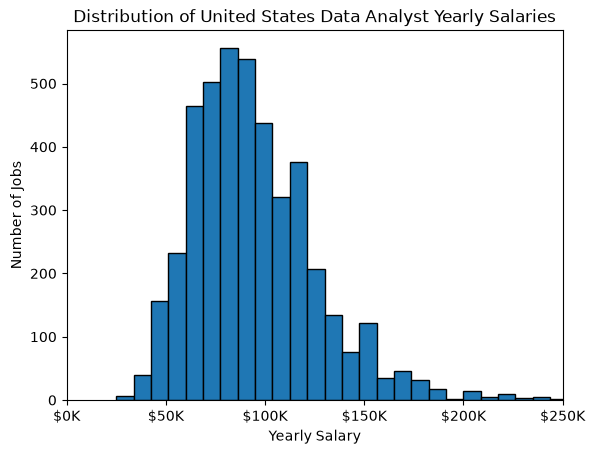

In [ ]:
#Histograms 

df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')
plt.xlim(0,250000)

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos : f'${int(x/1000)}K'))

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()

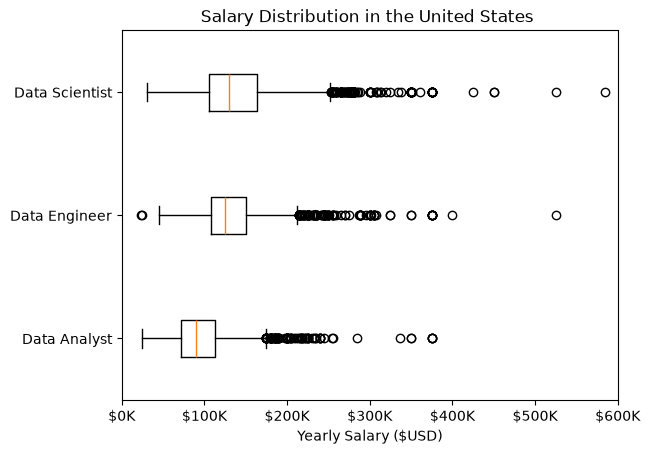

In [39]:
# Box plot

job_titles =['Data Analyst','Data Engineer','Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country']=='United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [ df_US[df_US['job_title_short']== job_title]['salary_year_avg'] for job_title in job_titles] 

plt.boxplot(job_list, tick_labels=job_titles, orientation='horizontal')
plt.title('Salary Distribution in the United States ')
plt.xlabel('Yearly Salary ($USD)')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos : f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()

#df_DA_US['salary_year_avg'].plot(kind='box', vert= False)

In [28]:
job_list[0]

109        89000.0
180        90250.0
410       133285.0
988        62623.0
1413       71300.0
            ...   
782637     70000.0
782798    111175.0
783588    125000.0
783866    115000.0
784882     87500.0
Name: salary_year_avg, Length: 4350, dtype: float64